# Task 2 — Neural CTR Prediction


In [1]:
!pip -q install scikit-learn pandas matplotlib
import torch; print(torch.__version__, 'GPU' if torch.cuda.is_available() else 'CPU')

2.11.0+cu128 GPU


## Data Loading


In [2]:
import os
from google.colab import files
DATA_DIR = "/content/datasets"
os.makedirs(DATA_DIR, exist_ok=True)
up = files.upload()                       # select the zip
for name, content in up.items():
    open(os.path.join(DATA_DIR, name), "wb").write(content)


Saving dataset (tasks 2 and 3) (1).zip to dataset (tasks 2 and 3) (1).zip


## Loading, preprocessing, training loop, metrics


In [3]:
import copy, glob, os, random, time, zipfile
import numpy as np
import pandas as pd
import torch
import json
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import (roc_auc_score, average_precision_score, log_loss, accuracy_score,
                             f1_score, precision_score, recall_score, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

### Loading


In [4]:
def _read(path, nrows=None):
    if path.endswith(".parquet"):
        df = pd.read_parquet(path)
        return df.head(nrows) if nrows else df
    df = pd.read_csv(path, nrows=nrows)
    if df.shape[1] == 1:                                   # probably tab separated
        df = pd.read_csv(path, sep="\t", nrows=nrows)
    return df


def load_data(data_dir, nrows=None):
    """Unzips (if needed), finds the train/test files, returns raw train_df, test_df, num_cols, cat_cols."""
    for z in glob.glob(os.path.join(data_dir, "*.zip")):
        out = os.path.join(data_dir, "_unzipped")
        if not os.path.exists(out):
            zipfile.ZipFile(z).extractall(out)
    files = [f for f in glob.glob(os.path.join(data_dir, "**", "*"), recursive=True)
             if f.lower().endswith((".csv", ".tsv", ".txt", ".parquet"))]
    tr_f = [f for f in files if "train" in os.path.basename(f).lower()]
    te_f = [f for f in files if "test" in os.path.basename(f).lower()]
    assert tr_f and te_f, f"could not find train/test files in {data_dir}: {files}"
    train, test = _read(tr_f[0], nrows), _read(te_f[0], nrows)
    feats = [c for c in train.columns if c != "label"]
    assert len(feats) == 39, f"expected 39 feature columns, got {len(feats)}: {feats}"
    NUM_COLS, CAT_COLS = feats[:13], feats[13:]            # <-- edit here if your column order differs
    return train, test, NUM_COLS, CAT_COLS

### Preprocessing (fit on train only → no leakage)


In [5]:
class Preprocessor:
    """
    Everything is FIT ON TRAIN ONLY (no leakage):
      numeric     : missing -> train median ; clip negatives to 0 ; log1p (counts are heavy tailed) ; standardise
      categorical : value -> integer id from a train vocabulary.  id 0 = rare/unseen/'UNK'.
                    Values seen < min_count times in train are mapped to 0 too (keeps embedding tables small
                    and teaches the UNK row what 'rare' looks like).
    """
    def __init__(self, min_count=5, max_vocab=100_000):
        self.min_count, self.max_vocab = min_count, max_vocab

    def _num(self, df):
        x = df[self.num_cols].astype(float).fillna(self.median).clip(lower=0)
        return np.log1p(x)
        # log1p(x) = log(1+x)
        # If the data contains highly skewed values, log transformation compresses them

    def fit(self, df, num_cols, cat_cols):
        self.num_cols, self.cat_cols = num_cols, cat_cols
        self.median = df[num_cols].astype(float).median()
        x = self._num(df)
        self.mean, self.std = x.mean(), x.std().replace(0, 1.0)
        self.vocab = {}
        for c in cat_cols:
            vc = df[c].astype(str).value_counts()
            vc = vc[vc >= self.min_count].head(self.max_vocab)
            self.vocab[c] = {v: i + 1 for i, v in enumerate(vc.index)}
        self.cards = [len(self.vocab[c]) + 1 for c in cat_cols]        # +1 for UNK
        return self

    def transform(self, df):
        dense = ((self._num(df) - self.mean) / self.std).values.astype(np.float32)
        sparse = np.stack([df[c].astype(str).map(self.vocab[c]).fillna(0).astype(np.int64).values
                           for c in self.cat_cols], axis=1)
        y = df["label"].values.astype(np.float32)
        return (torch.from_numpy(dense), torch.from_numpy(sparse), torch.from_numpy(y))


def prepare(data_dir, nrows=None, val_frac=0.1):
    """train file -> (train, val) stratified split ; test file untouched until the very end."""
    train_raw, test_raw, num_cols, cat_cols = load_data(data_dir, nrows)
    tr_df, va_df = train_test_split(train_raw, test_size=val_frac, random_state=SEED,
                                    stratify=train_raw["label"])
    pp = Preprocessor().fit(tr_df, num_cols, cat_cols)
    data = {"train": pp.transform(tr_df), "val": pp.transform(va_df), "test": pp.transform(test_raw),
            "cards": pp.cards, "n_dense": len(num_cols)}
    print(f"train={len(tr_df)} val={len(va_df)} test={len(test_raw)} | CTR train={tr_df.label.mean():.4f}"
          f" | total embedding rows={sum(pp.cards):,} | device={DEVICE}")
    return data, (tr_df, pp)

### Building blocks

In [6]:
def mlp(sizes, dropout=0.0, last_act=False):
    """sizes = [in, h1, ..., out].  ReLU between layers; optional ReLU after the last one."""
    layers = []
    for a, b in zip(sizes[:-1], sizes[1:]):
        layers += [nn.Linear(a, b), nn.ReLU()]
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
    if not last_act:
        layers = layers[:-2] if dropout > 0 else layers[:-1]           # drop trailing ReLU (+Dropout)
    return nn.Sequential(*layers)


def count_params(model):
    return sum(p.numel() for p in model.parameters())

### Training (Adam + BCE, early stopping on validation log-loss) and prediction

In [7]:
@torch.no_grad()
def predict(model, split, bs=8192):
    model.eval()
    dense, sparse, _ = split
    out = [torch.sigmoid(model(dense[i:i + bs].to(DEVICE), sparse[i:i + bs].to(DEVICE))).cpu()
           for i in range(0, len(dense), bs)]
    return torch.cat(out).numpy()


def fit(model, train, val, epochs=10, bs=2048, lr=1e-3, patience=2, verbose=True):
    """Adam + BCE-with-logits, early stopping on VALIDATION log-loss; restores the best weights."""
    model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.BCEWithLogitsLoss()
    dense, sparse, y = train
    n = len(y)
    hist = {"train_loss": [], "val_loss": [], "val_auc": []}
    best, best_state, bad = 1e9, None, 0
    t0 = time.time()
    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n)
        tot = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            d, s, t = dense[idx].to(DEVICE), sparse[idx].to(DEVICE), y[idx].to(DEVICE)
            opt.zero_grad()
            loss = lossf(model(d, s), t)
            loss.backward()
            opt.step()
            tot += loss.item() * len(idx)
        pv = predict(model, val)
        vl = log_loss(val[2].numpy(), np.clip(pv, 1e-7, 1 - 1e-7))
        va = roc_auc_score(val[2].numpy(), pv)
        hist["train_loss"].append(tot / n); hist["val_loss"].append(vl); hist["val_auc"].append(va)
        if verbose:
            print(f"   epoch {ep+1:2d}  train loss {tot/n:.4f}  val loss {vl:.4f}  val AUC {va:.4f}")
        if vl < best - 1e-5:
            best, best_state, bad = vl, copy.deepcopy(model.state_dict()), 0
        else:
            bad += 1
            if bad >= patience:
                print("   early stop"); break
    model.load_state_dict(best_state)
    return hist, time.time() - t0

### Evaluation
The decision threshold is picked on validation (best F1) and then applied to test.

In [8]:
def best_f1_threshold(y, p):
    """Pick the decision threshold on VALIDATION data (CTR is imbalanced, 0.5 is rarely optimal)."""
    pr, rc, th = precision_recall_curve(y, p)
    f1 = 2 * pr[:-1] * rc[:-1] / np.maximum(pr[:-1] + rc[:-1], 1e-12)
    return float(th[int(np.argmax(f1))])


def metrics(y, p, threshold):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    yh = (p >= threshold).astype(int)
    return {"roc_auc": roc_auc_score(y, p), "pr_auc": average_precision_score(y, p),
            "logloss": log_loss(y, p), "accuracy": accuracy_score(y, yh),
            "f1": f1_score(y, yh), "precision": precision_score(y, yh, zero_division=0),
            "recall": recall_score(y, yh), "threshold": threshold}


def evaluate(model, data):
    """threshold chosen on val, then applied to test."""
    yv, yt = data["val"][2].numpy(), data["test"][2].numpy()
    pv, pt = predict(model, data["val"]), predict(model, data["test"])
    th = best_f1_threshold(yv, pv)
    return metrics(yv, pv, th), metrics(yt, pt, th), pt

### Plots

In [9]:
def plot_curves(histories, path):
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    for name, h in histories.items():
        l, = ax[0].plot(h["val_loss"], label=f"{name} val")
        ax[0].plot(h["train_loss"], "--", color=l.get_color(), alpha=.6)
    ax[0].set(title="log-loss (solid = val, dashed = train)", xlabel="epoch"); ax[0].legend(fontsize=7)
    for name, h in histories.items():
        ax[1].plot(h["val_auc"], label=name)
    ax[1].set(title="validation ROC-AUC", xlabel="epoch"); ax[1].legend(fontsize=7)
    plt.tight_layout(); plt.savefig(path, dpi=130); plt.show()


def plot_calibration(y, preds, path):
    plt.figure(figsize=(5, 5))
    for name, p in preds.items():
        frac, mean = calibration_curve(y, p, n_bins=15, strategy="quantile")
        plt.plot(mean, frac, "o-", label=name, ms=3)
    lim = max(0.05, float(np.max([p.max() for p in preds.values()])))
    plt.plot([0, lim], [0, lim], "k--", label="perfect")
    plt.xlabel("mean predicted CTR"); plt.ylabel("observed CTR"); plt.title("Reliability (test)")
    plt.legend(fontsize=7); plt.tight_layout(); plt.savefig(path, dpi=130); plt.show()

## Models
VanillaNet must discover interactions by itself;

DCN adds explicit cross layers x_{l+1} = x0 · (wᵀx_l) + b + x_l.

In [10]:
class VanillaNet(nn.Module):
    """[dense(13) ; emb_1 ... emb_26] --concat--> MLP --> 1 logit.   The MLP must discover feature interactions on its own."""
    def __init__(self, cards, n_dense, emb_dim=16, hidden=(256, 128), dropout=0.2):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim) for c in cards])
        self.mlp = mlp([n_dense + len(cards) * emb_dim, *hidden, 1], dropout)

    def forward(self, dense, sparse):
        e = [emb(sparse[:, i]) for i, emb in enumerate(self.embs)]
        return self.mlp(torch.cat([dense, *e], dim=1)).squeeze(1)


class CrossLayer(nn.Module):
    """DCN cross layer:  x_{l+1} = x_0 * (w_l . x_l) + b_l + x_l
    (w.x is a scalar per sample, so each layer multiplies the ORIGINAL input by a learned projection of the current one
     -> the polynomial degree of the crosses grows by 1 per layer, with only 2d parameters)."""
    def __init__(self, d):
        super().__init__()
        self.w = nn.Linear(d, 1, bias=False)
        self.b = nn.Parameter(torch.zeros(d))

    def forward(self, x0, x):
        return x0 * self.w(x) + self.b + x


class DCN(nn.Module):
    """Cross network and deep network run in parallel on the same embedded input; outputs are concatenated."""
    def __init__(self, cards, n_dense, emb_dim=16, hidden=(256, 128), n_cross=3, dropout=0.2):
        super().__init__()
        self.embs = nn.ModuleList([nn.Embedding(c, emb_dim) for c in cards])
        d = n_dense + len(cards) * emb_dim
        self.cross = nn.ModuleList([CrossLayer(d) for _ in range(n_cross)])
        self.deep = mlp([d, *hidden], dropout, last_act=True)
        self.out = nn.Linear(d + hidden[-1], 1)

    def forward(self, dense, sparse):
        x0 = torch.cat([dense, *[emb(sparse[:, i]) for i, emb in enumerate(self.embs)]], dim=1)
        x = x0
        for layer in self.cross:
            x = layer(x0, x)
        return self.out(torch.cat([x, self.deep(x0)], dim=1)).squeeze(1)

## Config, data, exploration

In [11]:
NROWS = None          # e.g. 200_000 for a quick dry run
EPOCHS = 10
BS = 2048
OUT = "/content/outputs"; os.makedirs(OUT, exist_ok=True)     # to keep results: OUT = "/content/drive/MyDrive/outputs"

set_seed()
data, (tr_df, pp) = prepare(DATA_DIR, NROWS)
cards, nd = data["cards"], data["n_dense"]

train=36000 val=4000 test=10000 | CTR train=0.0320 | total embedding rows=10,970 | device=cuda


class balance:
 label
0    0.968
1    0.032
Name: proportion, dtype: float64

missing-value fraction (top 10):
 integer_feature_4         0.400
integer_feature_5         0.386
integer_feature_11        0.386
categorical_feature_14    0.364
categorical_feature_16    0.364
categorical_feature_17    0.364
categorical_feature_23    0.364
integer_feature_3         0.245
integer_feature_13        0.245
integer_feature_1         0.184
dtype: float64


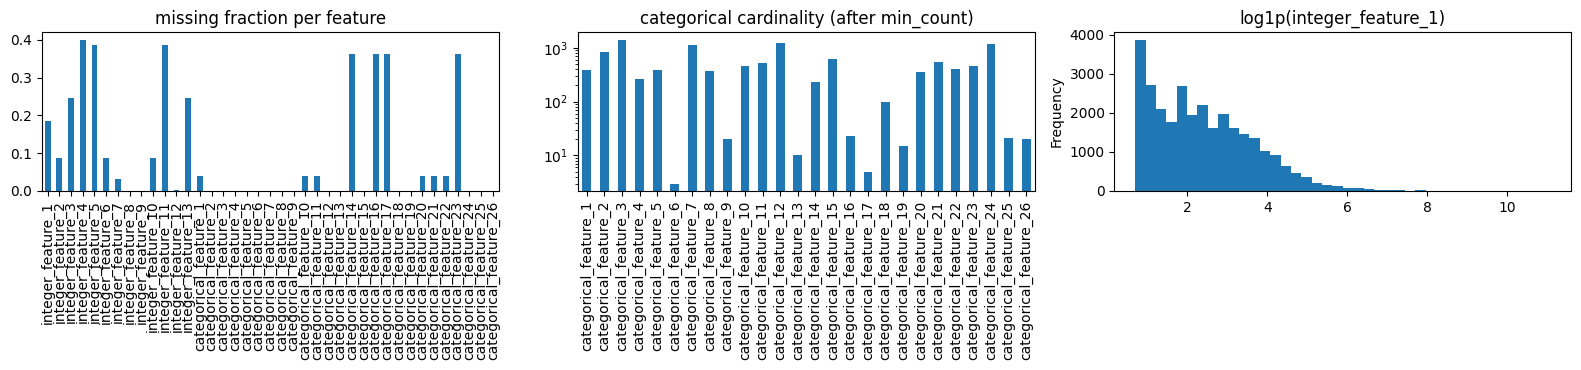

,mean,size
categorical_feature_1,,
ad98e872,0.022722,8186
265366bf,0.042536,5078
e5f3fd8d,0.040555,937
62770d79,0.051064,470
788a5d5b,0.019178,365
91c3c8e0,0.034921,315
217db914,0.007752,258
f669a734,0.000000,224
a97d405b,0.013699,146


In [12]:
# ---- EDA on the TRAIN part only
print("class balance:\n", tr_df.label.value_counts(normalize=True).round(4))
miss = tr_df[pp.num_cols + pp.cat_cols].isna().mean()
print("\nmissing-value fraction (top 10):\n", miss.sort_values(ascending=False).head(10).round(3))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
miss.plot.bar(ax=ax[0], title="missing fraction per feature")
pd.Series(pp.cards, index=pp.cat_cols).plot.bar(ax=ax[1], logy=True, title="categorical cardinality (after min_count)")
np.log1p(tr_df[pp.num_cols[0]].astype(float).clip(lower=0)).plot.hist(bins=40, ax=ax[2], title=f"log1p({pp.num_cols[0]})")
plt.tight_layout(); plt.show()

# CTR per top values of one categorical feature (does it carry signal?)
c = pp.cat_cols[0]
g = tr_df.groupby(c).label.agg(["mean", "size"]).sort_values("size", ascending=False).head(10)
display(g)

## Train and compare architectures

In [13]:
candidates = {
    "MLP-small (emb8, [64])":           lambda: VanillaNet(cards, nd, 8, (64,)),
    "MLP-medium (emb16, [256,128])":    lambda: VanillaNet(cards, nd, 16, (256, 128)),
    "MLP-deep (emb16, [512,256,128])":  lambda: VanillaNet(cards, nd, 16, (512, 256, 128)),
    "DCN (emb16, 3 cross + [256,128])": lambda: DCN(cards, nd, 16, (256, 128), 3),
}
DCN_NAME = "DCN (emb16, 3 cross + [256,128])"
hists, models, val_res, test_res, info = {}, {}, {}, {}, {}
for name, make in candidates.items():
    print(f"\n== {name}")
    set_seed()                                   # identical seed policy for every model
    m = make()
    hist, secs = fit(m, data["train"], data["val"], epochs=EPOCHS, bs=BS)
    v, t, pt = evaluate(m, data)
    hists[name], models[name] = hist, (m, pt)
    val_res[name], test_res[name] = v, t
    info[name] = {"params": count_params(m), "train_seconds": round(secs, 1), "param_MB_fp32": round(count_params(m) * 4 / 1e6, 1)}
    print(f"   val logloss {v['logloss']:.4f}  AUC {v['roc_auc']:.4f} | params {info[name]['params']:,}")


== MLP-small (emb8, [64])
   epoch  1  train loss 0.2951  val loss 0.1523  val AUC 0.5584
   epoch  2  train loss 0.1529  val loss 0.1483  val AUC 0.5985
   epoch  3  train loss 0.1483  val loss 0.1402  val AUC 0.6429
   epoch  4  train loss 0.1418  val loss 0.1375  val AUC 0.6698
   epoch  5  train loss 0.1401  val loss 0.1359  val AUC 0.6830
   epoch  6  train loss 0.1386  val loss 0.1349  val AUC 0.6935
   epoch  7  train loss 0.1364  val loss 0.1339  val AUC 0.7030
   epoch  8  train loss 0.1349  val loss 0.1331  val AUC 0.7107
   epoch  9  train loss 0.1343  val loss 0.1327  val AUC 0.7150
   epoch 10  train loss 0.1330  val loss 0.1324  val AUC 0.7180
   val logloss 0.1324  AUC 0.7180 | params 102,033

== MLP-medium (emb16, [256,128])
   epoch  1  train loss 0.2514  val loss 0.1644  val AUC 0.6027
   epoch  2  train loss 0.1460  val loss 0.1354  val AUC 0.6761
   epoch  3  train loss 0.1378  val loss 0.1336  val AUC 0.6899
   epoch  4  train loss 0.1335  val loss 0.1330  val AUC

## Model selection (validation only) and final test table

In [14]:
vanilla = [n for n in candidates if n.startswith("MLP")]
best_vanilla = min(vanilla, key=lambda n: val_res[n]["logloss"])
print("Selected vanilla architecture (best val log-loss):", best_vanilla)

table = pd.DataFrame({n: test_res[n] for n in candidates}).T.join(pd.DataFrame(info).T)
display(table.round(4))
table.round(5).to_csv(f"{OUT}/results_task2.csv")
json.dump({"selected_vanilla": best_vanilla, "test": test_res, "val": val_res, "info": info},
          open(f"{OUT}/results_task2.json", "w"), indent=2, default=float)

Selected vanilla architecture (best val log-loss): MLP-deep (emb16, [512,256,128])


,roc_auc,pr_auc,logloss,accuracy,f1,precision,recall,threshold,params,train_seconds,param_MB_fp32
"MLP-small (emb8, [64])",0.6789,0.0622,0.1418,0.8586,0.1140,0.0722,0.2716,0.0580,102033.0,4.1,0.4
"MLP-medium (emb16, [256,128])",0.7025,0.0792,0.1383,0.8956,0.1386,0.0958,0.2507,0.0716,318625.0,1.1,1.3
"MLP-deep (emb16, [512,256,128])",0.7001,0.0755,0.1384,0.9003,0.1398,0.0983,0.2418,0.0718,560033.0,0.6,2.2
"DCN (emb16, 3 cross + [256,128])",0.7046,0.0764,0.1386,0.9000,0.1349,0.0950,0.2328,0.0678,321628.0,0.9,1.3


## Training curves (overfitting check) and calibration

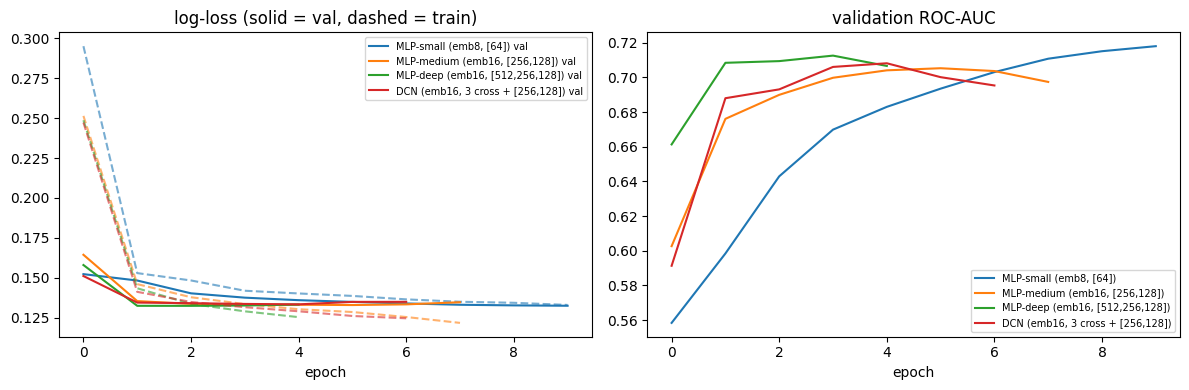

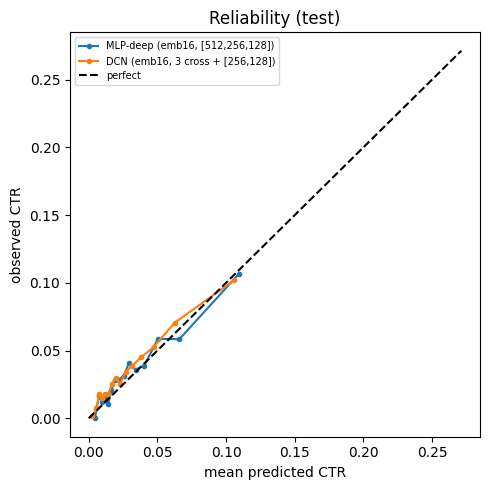

In [15]:
plot_curves(hists, f"{OUT}/task2_curves.png")
plot_calibration(data["test"][2].numpy(), {n: models[n][1] for n in (best_vanilla, DCN_NAME)}, f"{OUT}/task2_calibration.png")

## Conclusion

### 1. Overall Approach
The project predicts Click-Through Rate (CTR) using both numerical and categorical features. Categorical features are converted into learnable embeddings. These embeddings are combined with the preprocessed numerical features and passed to neural networks.

### 2. Model Comparison

Four models were evaluated:
* MLP-small: Lowest overall performance.
* MLP-medium: Improved performance with a larger embedding size and hidden layers.
* MLP-deep: Selected as the best vanilla MLP based on validation log-loss.
* DCN: Added an explicit cross network to learn feature interactions alongside the deep MLP branch.

### 3. Key Results
* MLP-deep
  + Accuracy: 0.9003 — highest
  + F1-score: 0.1398 — highest
  + Selected as the best vanilla architecture based on validation log-loss.
* DCN
  + ROC-AUC: 0.7046 — highest
  + This indicates strong ability to distinguish between clicked and non-clicked samples.
* MLP-medium
  + PR-AUC: 0.0792 — highest.
* MLP-small
  + Performed weakest across the main metrics.

### 4. Main Observation

Increasing the model capacity from MLP-small → MLP-medium → MLP-deep generally improved performance, although the improvement became relatively small among the larger models.

The DCN showed that explicitly modeling feature interactions can also be useful for CTR prediction.

